# Student Performance Analysis


## Objective:
#Analyze student exam performance using NumPy and Pandas to identify trends and factors affecting academic success.


#Pandas and Numpy added

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [159]:
# Step 2: Load the Dataset

In [160]:
sd = pd.read_csv("student_data.csv")

In [161]:
sd.rename(columns={"Medu":"Mother",
          "Fedu":"Father",
          "higher":"higherEdu",
          "romantic":"romanticRs"},
          inplace = True)
print(sd.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Mother',
       'Father', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime',
       'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higherEdu', 'internet', 'romanticRs', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')


## Explore the Dataset

In [162]:
sd.head(5)


,school,sex,age,address,famsize,Pstatus,Mother,Father,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [163]:
sd.tail(5)

,school,sex,age,address,famsize,Pstatus,Mother,Father,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [164]:
sd.shape

(395, 33)

In [165]:
sd.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Mother',
       'Father', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime',
       'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higherEdu', 'internet', 'romanticRs', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [166]:
sd.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Mother        int64
Father        int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higherEdu       str
internet        str
romanticRs      str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [167]:
sd.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Mother      395 non-null    int64
 7   Father      395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higherEdu   395 non-null    str  
 21  inte

In [168]:
sd.describe()

,age,Mother,Father,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## Clean Dataset


In [169]:
sd.isnull()


,school,sex,age,address,famsize,Pstatus,Mother,Father,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
391,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
392,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
393,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [170]:
sd.duplicated(keep = "first")

0      False
1      False
2      False
3      False
4      False
       ...  
390    False
391    False
392    False
393    False
394    False
Length: 395, dtype: bool

In [171]:
sd.drop_duplicates()

,school,sex,age,address,famsize,Pstatus,Mother,Father,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [172]:
sd.dtypes

school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Mother        int64
Father        int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higherEdu       str
internet        str
romanticRs      str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [173]:
for col in sd.columns:
    print(col)
    print(sd[col].unique())
    

school
<StringArray>
['GP', 'MS']
Length: 2, dtype: str
sex
<StringArray>
['F', 'M']
Length: 2, dtype: str
age
[18 17 15 16 19 22 20 21]
address
<StringArray>
['U', 'R']
Length: 2, dtype: str
famsize
<StringArray>
['GT3', 'LE3']
Length: 2, dtype: str
Pstatus
<StringArray>
['A', 'T']
Length: 2, dtype: str
Mother
[4 1 3 2 0]
Father
[4 1 2 3 0]
Mjob
<StringArray>
['at_home', 'health', 'other', 'services', 'teacher']
Length: 5, dtype: str
Fjob
<StringArray>
['teacher', 'other', 'services', 'health', 'at_home']
Length: 5, dtype: str
reason
<StringArray>
['course', 'other', 'home', 'reputation']
Length: 4, dtype: str
guardian
<StringArray>
['mother', 'father', 'other']
Length: 3, dtype: str
traveltime
[2 1 3 4]
studytime
[2 3 1 4]
failures
[0 3 2 1]
schoolsup
<StringArray>
['yes', 'no']
Length: 2, dtype: str
famsup
<StringArray>
['no', 'yes']
Length: 2, dtype: str
paid
<StringArray>
['no', 'yes']
Length: 2, dtype: str
activities
<StringArray>
['no', 'yes']
Length: 2, dtype: str
nursery
<Stri

In [174]:
sd["G1"].between(0,20)

0      True
1      True
2      True
3      True
4      True
       ... 
390    True
391    True
392    True
393    True
394    True
Name: G1, Length: 395, dtype: bool

In [175]:
sd["G2"].between(0,20)

0      True
1      True
2      True
3      True
4      True
       ... 
390    True
391    True
392    True
393    True
394    True
Name: G2, Length: 395, dtype: bool

In [176]:
sd["G3"].between(0,20)

0      True
1      True
2      True
3      True
4      True
       ... 
390    True
391    True
392    True
393    True
394    True
Name: G3, Length: 395, dtype: bool

In [177]:
sd["age"].between(15,22)

0      True
1      True
2      True
3      True
4      True
       ... 
390    True
391    True
392    True
393    True
394    True
Name: age, Length: 395, dtype: bool

## Phase 3: Feature Engineering


In [178]:
sd["Total"] = sd["G1"] + sd["G2"] + sd["G3"]
print(sd)


    school sex  age address famsize Pstatus  Mother  Father      Mjob  \
0       GP   F   18       U     GT3       A       4       4   at_home   
1       GP   F   17       U     GT3       T       1       1   at_home   
2       GP   F   15       U     LE3       T       1       1   at_home   
3       GP   F   15       U     GT3       T       4       2    health   
4       GP   F   16       U     GT3       T       3       3     other   
..     ...  ..  ...     ...     ...     ...     ...     ...       ...   
390     MS   M   20       U     LE3       A       2       2  services   
391     MS   M   17       U     LE3       T       3       1  services   
392     MS   M   21       R     GT3       T       1       1     other   
393     MS   M   18       R     LE3       T       3       2  services   
394     MS   M   19       U     LE3       T       1       1     other   

         Fjob  ... freetime goout  Dalc  Walc  health absences  G1  G2  G3  \
0     teacher  ...        3     4     1     1

In [179]:
sd["Average"] = sd["Total"]/3
print(sd)


    school sex  age address famsize Pstatus  Mother  Father      Mjob  \
0       GP   F   18       U     GT3       A       4       4   at_home   
1       GP   F   17       U     GT3       T       1       1   at_home   
2       GP   F   15       U     LE3       T       1       1   at_home   
3       GP   F   15       U     GT3       T       4       2    health   
4       GP   F   16       U     GT3       T       3       3     other   
..     ...  ..  ...     ...     ...     ...     ...     ...       ...   
390     MS   M   20       U     LE3       A       2       2  services   
391     MS   M   17       U     LE3       T       3       1  services   
392     MS   M   21       R     GT3       T       1       1     other   
393     MS   M   18       R     LE3       T       3       2  services   
394     MS   M   19       U     LE3       T       1       1     other   

         Fjob  ... goout Dalc  Walc  health  absences  G1  G2  G3 Total  \
0     teacher  ...     4    1     1       3     

In [180]:
def grading(avg):
    if avg > 16:
        return "Excellent"
    elif avg > 12:
        return "Good"
    elif avg > 8:
        return "Average"
    else:
        return "Poor"

sd["Performance"] = sd["Average"].apply(grading)
print(sd)

    school sex  age address famsize Pstatus  Mother  Father      Mjob  \
0       GP   F   18       U     GT3       A       4       4   at_home   
1       GP   F   17       U     GT3       T       1       1   at_home   
2       GP   F   15       U     LE3       T       1       1   at_home   
3       GP   F   15       U     GT3       T       4       2    health   
4       GP   F   16       U     GT3       T       3       3     other   
..     ...  ..  ...     ...     ...     ...     ...     ...       ...   
390     MS   M   20       U     LE3       A       2       2  services   
391     MS   M   17       U     LE3       T       3       1  services   
392     MS   M   21       R     GT3       T       1       1     other   
393     MS   M   18       R     LE3       T       3       2  services   
394     MS   M   19       U     LE3       T       1       1     other   

         Fjob  ... Dalc Walc  health  absences  G1  G2  G3 Total    Average  \
0     teacher  ...    1    1       3        

In [181]:
def pf(g3):
    if g3 >= 10:
        return "Pass"
    elif g3 > 0:
        return "Fail"
    else:
        return "Incomplete"
    
sd["Pass/Fail"] = sd["G3"].apply(pf)
print(sd)

    school sex  age address famsize Pstatus  Mother  Father      Mjob  \
0       GP   F   18       U     GT3       A       4       4   at_home   
1       GP   F   17       U     GT3       T       1       1   at_home   
2       GP   F   15       U     LE3       T       1       1   at_home   
3       GP   F   15       U     GT3       T       4       2    health   
4       GP   F   16       U     GT3       T       3       3     other   
..     ...  ..  ...     ...     ...     ...     ...     ...       ...   
390     MS   M   20       U     LE3       A       2       2  services   
391     MS   M   17       U     LE3       T       3       1  services   
392     MS   M   21       R     GT3       T       1       1     other   
393     MS   M   18       R     LE3       T       3       2  services   
394     MS   M   19       U     LE3       T       1       1     other   

         Fjob  ... Walc health  absences  G1  G2  G3 Total    Average  \
0     teacher  ...    1      3         6   5   6  

In [182]:
sd["ParentEdu"] = (sd["Mother"] + sd["Father"])/2
print(sd)

    school sex  age address famsize Pstatus  Mother  Father      Mjob  \
0       GP   F   18       U     GT3       A       4       4   at_home   
1       GP   F   17       U     GT3       T       1       1   at_home   
2       GP   F   15       U     LE3       T       1       1   at_home   
3       GP   F   15       U     GT3       T       4       2    health   
4       GP   F   16       U     GT3       T       3       3     other   
..     ...  ..  ...     ...     ...     ...     ...     ...       ...   
390     MS   M   20       U     LE3       A       2       2  services   
391     MS   M   17       U     LE3       T       3       1  services   
392     MS   M   21       R     GT3       T       1       1     other   
393     MS   M   18       R     LE3       T       3       2  services   
394     MS   M   19       U     LE3       T       1       1     other   

         Fjob  ... health absences  G1  G2  G3 Total    Average Performance  \
0     teacher  ...      3        6   5   6  

In [183]:
sd["TotalAlc"] = sd["Walc"] + sd["Dalc"]
print(sd)


    school sex  age address famsize Pstatus  Mother  Father      Mjob  \
0       GP   F   18       U     GT3       A       4       4   at_home   
1       GP   F   17       U     GT3       T       1       1   at_home   
2       GP   F   15       U     LE3       T       1       1   at_home   
3       GP   F   15       U     GT3       T       4       2    health   
4       GP   F   16       U     GT3       T       3       3     other   
..     ...  ..  ...     ...     ...     ...     ...     ...       ...   
390     MS   M   20       U     LE3       A       2       2  services   
391     MS   M   17       U     LE3       T       3       1  services   
392     MS   M   21       R     GT3       T       1       1     other   
393     MS   M   18       R     LE3       T       3       2  services   
394     MS   M   19       U     LE3       T       1       1     other   

         Fjob  ... absences  G1  G2  G3  Total    Average Performance  \
0     teacher  ...        6   5   6   6     17   5

## Phase 4: EDA


In [184]:
sd[["G1", "G2", "G3", "Total", "Average", "absences", "TotalAlc", "ParentEdu"]].describe().round(2)

,G1,G2,G3,Total,Average,absences,TotalAlc,ParentEdu
count,395.00,395.00,395.00,395.00,395.00,395.00,395.00,395.00
mean,10.91,10.71,10.42,32.04,10.68,5.71,3.77,2.64
std,3.32,3.76,4.58,11.09,3.70,8.00,1.98,0.98
min,3.00,0.00,0.00,4.00,1.33,0.00,2.00,0.50
25%,8.00,9.00,8.00,25.00,8.33,0.00,2.00,2.00
50%,11.00,11.00,11.00,32.00,10.67,4.00,3.00,2.50
75%,13.00,13.00,14.00,40.00,13.33,8.00,5.00,3.50
max,19.00,19.00,20.00,58.00,19.33,75.00,10.00,4.00


## Univariate Analysis — Numeric Columns


- G1→G3 shows a slight downward drift in mean score (10.91 → 10.42)
- G2 and G3 have min=0 (Incomplete cases); G1 does not (min=3)
- Absences are heavily right-skewed: mean (5.71) > median (4.0), 
  std (8.00) exceeds the mean — a few extreme outliers are driving this
- Class average (10.68) sits just above the pass threshold (10) — 
  performance overall is borderline
- TotalAlc and ParentEdu both show mid-to-low central tendency, 
  no major skew

In [185]:
for col in ["Performance", "Pass/Fail", "sex", "school"]:
    print(sd[col].value_counts())

Performance
Average      158
Good         118
Poor          94
Excellent     25
Name: count, dtype: int64
Pass/Fail
Pass          265
Fail           92
Incomplete     38
Name: count, dtype: int64
sex
F    208
M    187
Name: count, dtype: int64
school
GP    349
MS     46
Name: count, dtype: int64


## Univariate Analysis — Categorical Columns

- Performance: Average is the largest group (158, ~40%), Excellent the smallest 
  (25, ~6%) — performance skews toward the lower-middle overall
- Pass/Fail: 265 passed (~67%), but 130 students (~33%) either failed (92) 
  or didn't complete finals (38) — roughly 1 in 3 students didn't pass
- Performance (94 "Poor") and Pass/Fail (130 non-passers) don't fully align, 
  since Performance uses the 3-grade average while Pass/Fail uses G3 only
- Sex is fairly balanced: 208 F vs 187 M
- School is heavily imbalanced: 349 GP vs 46 MS — any GP vs MS comparison 
  later should account for this small MS sample size

In [186]:
for col in ["Mjob","Fjob","internet","romanticRs","higherEdu"]:
   print(sd[col].value_counts())

Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64
internet
yes    329
no      66
Name: count, dtype: int64
romanticRs
no     263
yes    132
Name: count, dtype: int64
higherEdu
yes    375
no      20
Name: count, dtype: int64


## Univariate Analysis — Categorical Columns (Part 2)

- Mjob and Fjob are both dominated by "other" (36% and 55% respectively), 
  limiting how useful these columns are for detailed job-based comparisons
- at_home is far more common for mothers (59) than fathers (20) — 
  reflects a real gender pattern in this sample
- internet: 83% yes vs 17% no — comparisons involving the "no" group 
  should be treated cautiously due to small sample size (66)
- romantic: 67% no vs 33% yes — reasonably usable split
- higher: 95% yes vs 5% no (only 20 students) — very low variation, 
  weak column for finding differences; "no" group too small to generalize from

In [187]:
sd.groupby("studytime")["G3"].mean().round(2)


studytime
1    10.05
2    10.17
3    11.40
4    11.26
Name: G3, dtype: float64

In [188]:
sd["studytime"].value_counts()

studytime
2    198
1    105
3     65
4     27
Name: count, dtype: int64

## Bivariate — Studytime vs G3

- Clear upward trend from studytime 1 (10.05) to studytime 3 (11.40)
- Slight dip at studytime 4 (11.26), but this group only has 27 students 
  (vs 198 at studytime 2) — likely sample size noise, not a real reversal
- Overall conclusion: more study time is generally associated with 
  higher G3, though the relationship isn't perfectly linear

In [189]:
sd.groupby("failures")["G3"].mean().round(2)


failures
0    11.25
1     8.12
2     6.24
3     5.69
Name: G3, dtype: float64

In [190]:
sd["failures"].value_counts()

failures
0    312
1     50
2     17
3     16
Name: count, dtype: int64

## Bivariate — Failures vs G3

- Strong, consistent downward trend: 11.25 → 8.12 → 6.24 → 5.69 
  as failures go from 0 to 3
- Much larger spread (~5.6 points) than studytime (~1.35 points) — 
  failures appears to be a stronger predictor of G3 than studytime
- Biggest single drop is between 0 and 1 failure (11.25 → 8.12)
- Groups 2 and 3 are small (17 and 16 students) so exact values are 
  less precise, but the consistent downward direction across all 
  groups makes the overall trend credible
- Sample sizes drop sharply: 312 students have 0 failures vs only 
  16 with 3 failures — most students in this dataset have never failed

In [191]:
sd.groupby("sex")["G3"].mean().round(2)

sex
F     9.97
M    10.91
Name: G3, dtype: float64

In [192]:
sd["sex"].value_counts()

sex
F    208
M    187
Name: count, dtype: int64

In [193]:
sd.groupby("sex")["studytime"].mean().round(2)

sex
F    2.28
M    1.76
Name: studytime, dtype: float64

In [194]:
sd.groupby("sex")["goout"].mean().round(2)

sex
F    3.03
M    3.20
Name: goout, dtype: float64

In [195]:
sd.groupby("sex")["failures"].mean().round(2)

sex
F    0.30
M    0.37
Name: failures, dtype: float64

## Bivariate — Sex vs G3 (deeper look)

- Females show MORE favorable indicators than males: higher studytime 
  (2.28 vs 1.76), lower goout (3.03 vs 3.20), fewer failures (0.30 vs 0.37)
- Despite this, females still average LOWER G3 (9.97) than males (10.91)
- This means studytime/goout/failures do NOT explain the sex-based 
  performance gap — something else is driving it that isn't captured 
  in these three variables
- Notable, honest finding: not all patterns have a clean explanation — 
  worth flagging as a limitation/open question in final insights (Phase 7)

In [196]:
sd.groupby("TotalAlc")["G3"].mean().round(2)

TotalAlc
2     10.81
3     10.27
4     10.37
5     10.56
6      9.00
7     10.24
8     10.44
9      9.75
10    10.67
Name: G3, dtype: float64

In [197]:
sd["TotalAlc"].value_counts()

TotalAlc
2     150
3      66
4      60
5      45
6      35
7      17
10      9
8       9
9       4
Name: count, dtype: int64

## Bivariate — TotalAlc vs G3

- No clear or consistent trend across TotalAlc levels (2 through 10) — 
  averages bounce between ~9.0 and ~10.8 without a steady direction
- Group sizes shrink drastically at higher TotalAlc values 
  (e.g., only 4-9 students at TotalAlc 8, 9, 10), making those 
  specific averages unreliable
- Conclusion: unlike failures, TotalAlc does not show a strong or 
  reliable relationship with G3 in this dataset — worth noting as 
  a "no clear effect found" result rather than forcing a pattern

In [198]:
sd.groupby("ParentEdu")["G3"].mean().round(2)


ParentEdu
0.5    12.50
1.0     8.64
1.5     9.26
2.0     9.60
2.5    10.40
3.0    11.30
3.5    10.95
4.0    11.66
Name: G3, dtype: float64

In [199]:
sd["ParentEdu"].value_counts()

ParentEdu
2.0    72
4.0    70
3.0    64
3.5    58
2.5    47
1.5    43
1.0    39
0.5     2
Name: count, dtype: int64

## Bivariate — ParentEdu vs G3

- Clear upward trend from ParentEdu 1.0 (8.64) to 4.0 (11.66), 
  with a small dip at 3.5 (10.95) — overall supports "higher parental 
  education associates with higher G3"
- ParentEdu = 0.5 shows the highest average (12.50) but is based on 
  only 2 students — not statistically meaningful, excluded from the 
  overall trend interpretation
- Group sizes for 1.0 through 4.0 are all reasonably large (39-72 
  students each), making this trend reliable

In [200]:
sd.groupby("schoolsup")["G3"].mean().round(2)

schoolsup
no     10.56
yes     9.43
Name: G3, dtype: float64

In [201]:
sd["schoolsup"].value_counts()

schoolsup
no     344
yes     51
Name: count, dtype: int64

## Bivariate — schoolsup vs G3

- Students without school support average HIGHER G3 (10.56, n=344) 
  than students with support (9.43, n=51)
- Important: this does NOT mean support causes lower grades — 
  schoolsup is likely given to already-struggling students, so the 
  gap reflects pre-existing difficulty, not an effect of the support
- Cannot determine causation from this comparison alone — a genuine 
  limitation to flag in Phase 7, not a finding to overstate

##Phase 5: GroupBy Analysis


In [202]:
sd.groupby("studytime")["G3"].agg(["mean","max","min","count"]).round(2)

,mean,max,min,count
studytime,,,,
1,10.05,19,0,105
2,10.17,19,0,198
3,11.40,19,0,65
4,11.26,20,0,27


## GroupBy Analysis — Studytime (mean, min, max, count)

- Every studytime group has a min of 0 — Incomplete/zero-scoring 
  students exist at every study level, even studytime=4
- Max scores are nearly identical across all groups (19-20) — 
  top performers exist even at studytime=1
- The mean trend (10.05 → 11.26) still holds, but the wide range 
  within each group shows studytime shifts the average without 
  guaranteeing any individual outcome
- Confirms: studytime is associated with performance at the group 
  level, but individual variation remains high regardless of studytime

In [203]:
sd.groupby(["studytime","sex"])["G3"].agg(["mean","count"]).round(2)

mean  count
studytime sex              
1         F     9.85     27
          M    10.12     78
2         F     9.50    113
          M    11.07     85
3         F    10.73     51
          M    13.86     14
4         F    11.00     17
          M    11.70     10

## GroupBy Analysis — Studytime x Sex vs G3 (with counts)

- Group size does NOT explain the sex gap — there's no consistent 
  relationship between which sex is the bigger group and which 
  scores lower (e.g., males are the smaller group at studytime=4 
  yet still score higher)
- The sex gap (males > females) holds at every studytime level 
  regardless of group size, confirming this is a real pattern, 
  not a sample-size artifact
- Specific values built on small groups (studytime=3 males, n=14; 
  studytime=4 males, n=10) should be read cautiously — they're 
  less stable estimates, but don't change the overall direction 
  of the gap

In [204]:
sd.groupby(["romanticRs","sex"])["G3"].agg(["mean","count"]).round(2)

mean  count
romanticRs sex              
no         F    10.55    129
           M    11.11    134
yes        F     9.01     79
           M    10.42     53

## GroupBy Analysis — Romantic x Sex vs G3

- Sex gap persists in both groups: males > females whether or not 
  they're in a relationship
- Gap widens when in a relationship: 0.56 (not in relationship) 
  vs 1.41 (in relationship)
- Key insight: being in a relationship is associated with LOWER G3 
  for both sexes, but the drop is much steeper for females (-1.54) 
  than for males (-0.69)
- All group sizes are reasonably large (53-134), so this pattern 
  is reliable, not a small-sample artifact
- This is one of the more specific findings so far: romantic status 
  doesn't just correlate with grades — it interacts differently by sex

## Phase 6: Pivot Tables


In [205]:
pd.pivot_table(sd,
               values = "G3",
               index = "studytime",
               columns = "sex",
               aggfunc= "mean").round(2)

sex,F,M
studytime,,
1,9.85,10.12
2,9.50,11.07
3,10.73,13.86
4,11.00,11.70


In [206]:
pd.pivot_table(sd,
               values = "G3",
               index = "school",
               columns = "sex",
               aggfunc= ["mean","count"]).round(2)

mean        count     
sex        F      M     F    M
school                        
GP      9.97  11.06   183  166
MS      9.92   9.76    25   21

## Pivot Table — School x Sex vs G3

- At GP school: males average notably higher than females (11.06 vs 9.97, 
  gap ~1.09) — matches the overall pattern found earlier
- At MS school: males and females are nearly identical (9.76 vs 9.92) — 
  the sex gap essentially disappears
- GP counts are large and reliable (183 F, 166 M); MS counts are much 
  smaller (25 F, 21 M) — the MS near-tie should be read cautiously, 
  not as strong evidence that no gap exists there
- Key refinement: the sex gap found throughout this project appears 
  concentrated at GP school, not a universal pattern across both schools

In [207]:
pd.pivot_table(sd,
               values = "G3",
               index = "Performance",
               columns = "Pass/Fail",
               aggfunc= ["mean","count"]).round(2)

mean                   count                  
Pass/Fail    Fail Incomplete   Pass  Fail Incomplete   Pass
Performance                                                
Average      8.67        NaN  10.76  36.0        NaN  122.0
Excellent     NaN        NaN  17.92   NaN        NaN   25.0
Good          NaN        NaN  14.01   NaN        NaN  118.0
Poor         6.93        0.0    NaN  56.0       38.0    NaN

## Pivot Table — Performance x Pass/Fail

- Excellent (25) and Good (118) students always Pass — average-based 
  Performance and G3-based Pass/Fail fully agree at the top end
- Poor students (94 total) split into Fail (56) and Incomplete (38) — 
  two distinct situations: genuinely low scorers vs. disengaged/absent 
  from finals
- KEY FINDING: Average-performance students split into Fail (36) and 
  Pass (122) — this resolves the earlier mismatch (94 Poor vs 130 
  total non-passers). These 36 students had a decent overall average 
  but still failed their final exam specifically — suggesting a 
  late decline rather than year-long struggle
- Incomplete students always show mean G3 = 0.0 (by definition), 
  confirming the Pass/Fail logic is working correctly

# Phase 7: Insights and Conclusions

## 1. Dataset Overview
This dataset contains records for 395 students from two Portuguese secondary 
schools — Gabriel Pereira (GP, 349 students) and Mousinho da Silveira 
(MS, 46 students). It includes demographic, family background, lifestyle, 
and academic performance data (G1, G2, G3 grades on a 0–20 scale).

## 2. Data Quality Notes
- No major missing values or duplicate rows were found in the raw dataset.
- `absences` showed strong right-skew, with a small number of extreme 
  outliers (54, 56, 75 days) pulling the mean well above the median.
- A number of students had G3 = 0 while G1/G2 had real scores — interpreted 
  as students who did not sit the final exam, not as a true zero score. 
  These were separated into an "Incomplete" category rather than merged 
  into "Fail," preserving an important distinction in the data.

## 3. Feature Engineering Summary
The following features were created to support deeper analysis:
- **Total / Average** — combined G1+G2+G3 into a single performance score
- **Performance** — categorical label (Excellent / Good / Average / Poor) 
  based on Average
- **Pass/Fail** — Pass (G3≥10) / Fail (0<G3<10) / Incomplete (G3=0), based 
  specifically on the final grade
- **ParentEdu** — average of Medu and Fedu, representing household 
  education level
- **TotalAlc** — combined weekday + weekend alcohol consumption (Dalc+Walc)

## 4. Key Findings

### Strong, well-supported patterns
- **Past failures is the strongest predictor of G3.** Average G3 drops 
  consistently and sharply as failures increase: 11.25 (0 failures) → 8.12 
  (1) → 6.24 (2) → 5.69 (3). The trend is monotonic across all groups.
- **Study time shows a genuine, though imperfect, positive relationship 
  with G3.** Average G3 rises from 10.05 (studytime=1) to 11.40 
  (studytime=3), with a small dip at studytime=4 (11.26) likely explained 
  by that group's small size (n=27).
- **Parental education correlates positively with G3.** Average G3 rises 
  from 8.64 (ParentEdu=1.0) to 11.66 (ParentEdu=4.0), a solid upward trend 
  across well-populated groups (39–72 students each).
- **A persistent, unexplained sex gap exists in performance.** Males 
  average higher G3 than females overall (10.91 vs 9.97), and this holds 
  at every studytime level and in both romantic-status groups. Notably, 
  females report *better* study habits, *lower* goout, and *fewer* 
  failures than males — meaning this gap is not explained by any of the 
  behavioral factors examined here.
- **The sex gap is concentrated at GP school.** At GP, males outperform 
  females by ~1.09 points; at MS, the gap nearly disappears (males and 
  females are almost identical). MS's smaller sample size (46 students) 
  means this should be treated as a directional finding, not a conclusive one.
- **Romantic relationships associate with lower G3 for both sexes, but 
  far more so for females.** Females in a relationship drop 1.54 points 
  on average compared to those not in one; males drop only 0.69 points. 
  This is one of the more specific, well-supported findings in the project.

### Findings requiring careful interpretation (correlation ≠ causation)
- **Students receiving school support (schoolsup) average lower G3** 
  (9.43 vs 10.56). This does not mean support harms performance — support 
  is typically given to students already struggling, so the gap likely 
  reflects pre-existing difficulty rather than an effect of the support 
  itself.

### Weak or inconclusive patterns
- **TotalAlc (combined alcohol consumption) shows no clear or reliable 
  trend with G3.** Averages bounce between ~9.0 and ~10.8 with no 
  consistent direction, and sample sizes collapse sharply at higher 
  consumption levels (as few as 4–9 students). This is an honest 
  "no strong effect found" result rather than a confirmed relationship.

### A distinct sub-group worth noting
- Cross-referencing `Performance` and `Pass/Fail` revealed that all 
  Excellent/Good students passed, and all Poor students either failed 
  or were Incomplete — but 36 students labeled "Average" (a decent 
  overall grade average) still failed their final exam specifically. 
  This suggests a subgroup of students who performed adequately across 
  the year but declined sharply at the final exam — a different 
  situation than students who struggled consistently all year.

## 5. Limitations
- The dataset is heavily imbalanced by school (349 GP vs 46 MS) — any 
  GP vs MS comparison should be read with reduced confidence on the MS side.
- Several subgroup breakdowns (e.g., studytime=4, TotalAlc=9/10, 
  ParentEdu=0.5) are based on very few students and should not be 
  over-interpreted.
- Relationships found here (e.g., schoolsup, sex) are correlational, 
  not causal — the data cannot determine *why* these patterns exist, 
  only that they do.

## 6. Final Takeaway
Past academic failures are, by a clear margin, the strongest factor 
associated with lower final grades in this dataset. Study habits and 
parental education show meaningful but more modest positive associations 
with performance. A consistent sex-based performance gap exists that is 
not explained by studytime, goout, or failure history — favoring males, 
concentrated primarily at GP school, and widening notably for students 
in romantic relationships. Alcohol consumption, despite being a commonly 
assumed factor in student performance, showed no reliable relationship 
with grades in this particular dataset.

## Phase 8: Matplotlib visualizations


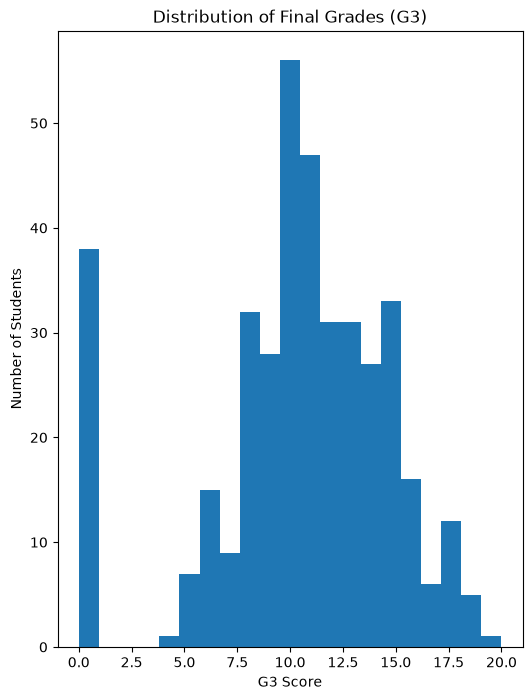

In [208]:
fig , ax = plt.subplots(figsize=(6,8))
ax.hist(sd["G3"], bins=21)
ax.set_title("Distribution of Final Grades (G3)")
ax.set_xlabel("G3 Score")
ax.set_ylabel("Number of Students")

plt.show()

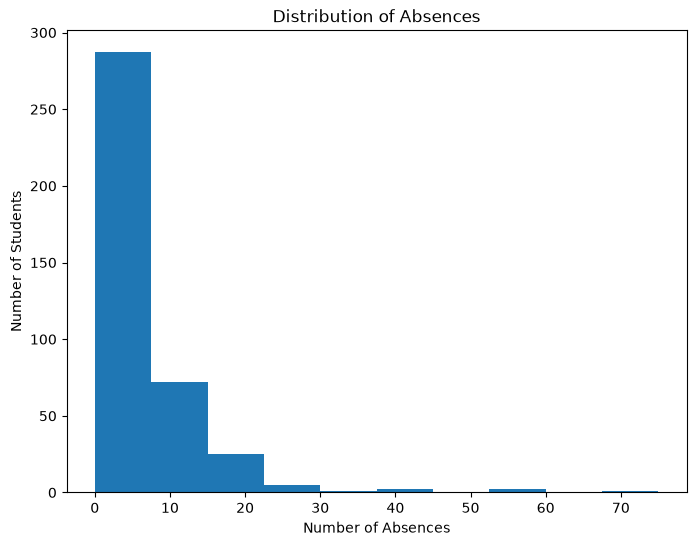

In [211]:
fig, ax = plt.subplots(figsize=(8,6))
ax.hist(sd["absences"])
ax.set_title("Distribution of Absences")
ax.set_xlabel("Number of Absences")
ax.set_ylabel("Number of Students")
plt.show()

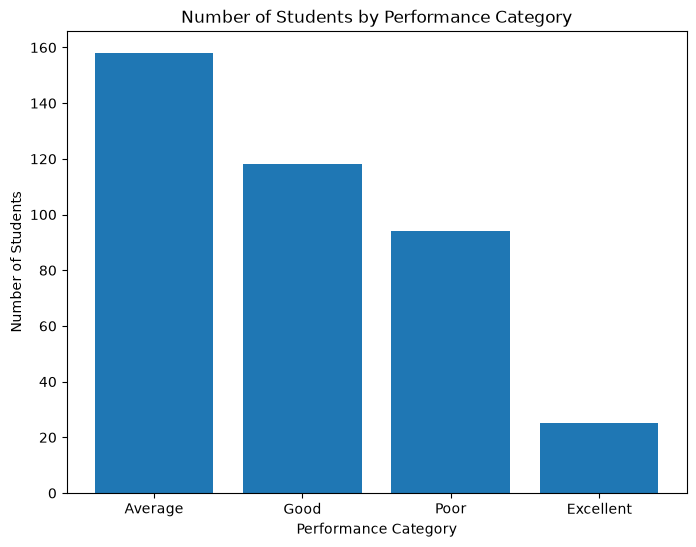

In [214]:
performance_counts = sd["Performance"].value_counts()

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(performance_counts.index, performance_counts.values)
ax.set_title("Number of Students by Performance Category")
ax.set_xlabel("Performance Category")
ax.set_ylabel("Number of Students")
plt.show()

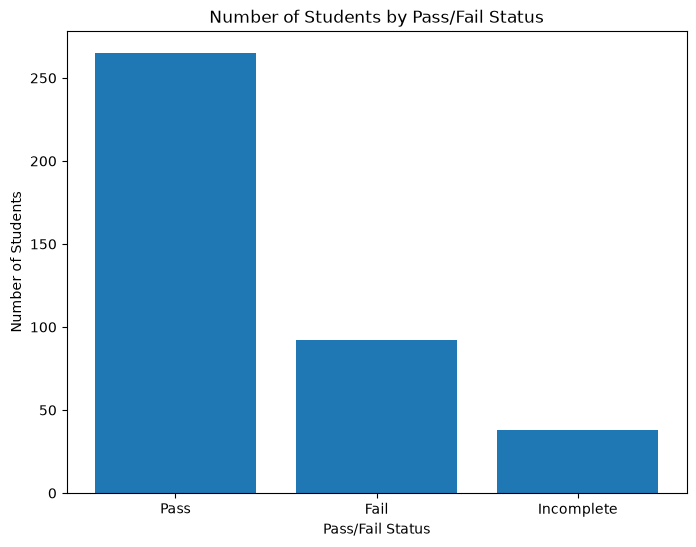

In [215]:
passfail_counts = sd["Pass/Fail"].value_counts()

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(passfail_counts.index, passfail_counts.values)
ax.set_title("Number of Students by Pass/Fail Status")
ax.set_xlabel("Pass/Fail Status")
ax.set_ylabel("Number of Students")
plt.show()

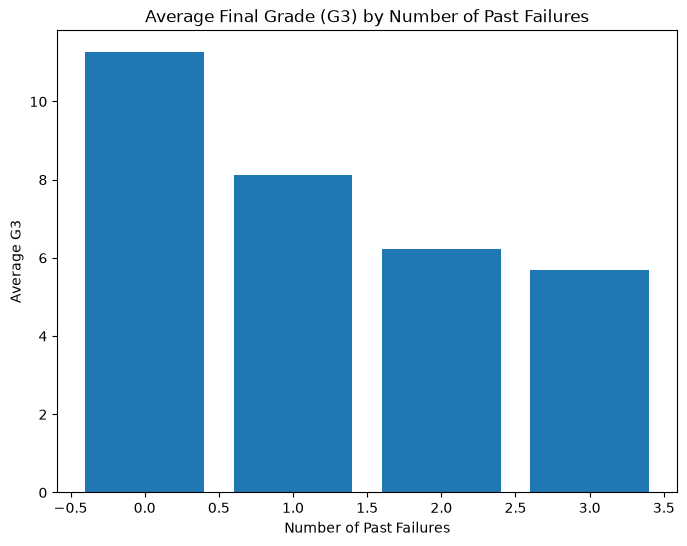

In [216]:
failures_g3 = sd.groupby("failures")["G3"].mean()

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(failures_g3.index, failures_g3.values)
ax.set_title("Average Final Grade (G3) by Number of Past Failures")
ax.set_xlabel("Number of Past Failures")
ax.set_ylabel("Average G3")
plt.show()

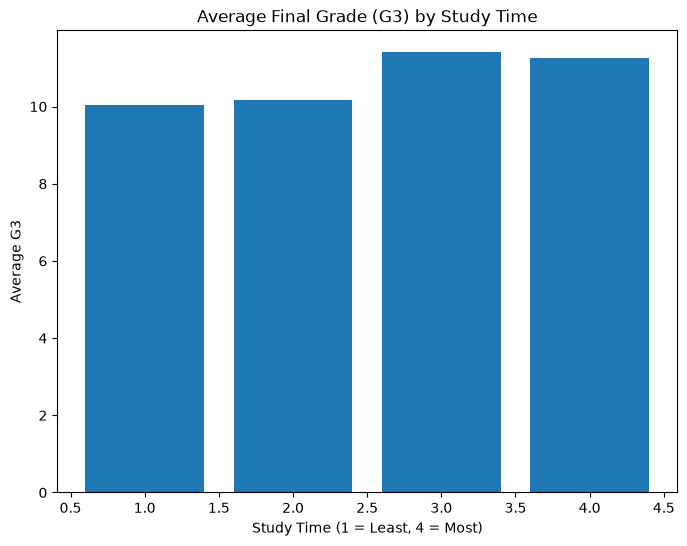

In [217]:
studytime_g3 = sd.groupby("studytime")["G3"].mean()

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(studytime_g3.index, studytime_g3.values)
ax.set_title("Average Final Grade (G3) by Study Time")
ax.set_xlabel("Study Time (1 = Least, 4 = Most)")
ax.set_ylabel("Average G3")
plt.show()

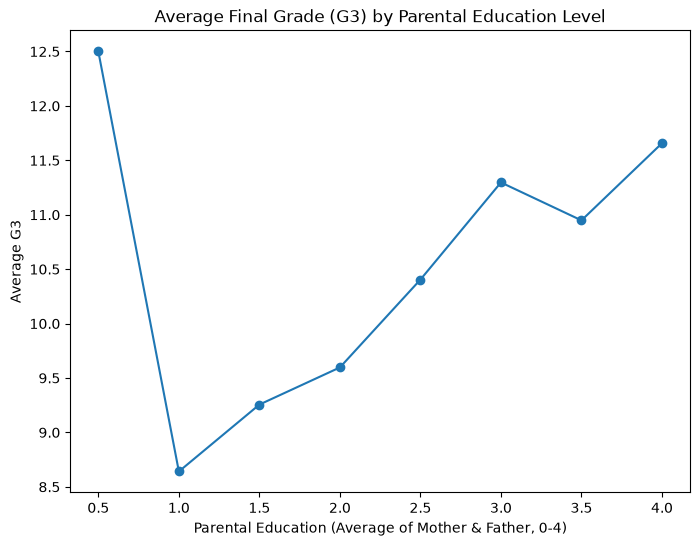

In [218]:
parentedu_g3 = sd.groupby("ParentEdu")["G3"].mean()

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(parentedu_g3.index, parentedu_g3.values, marker="o")
ax.set_title("Average Final Grade (G3) by Parental Education Level")
ax.set_xlabel("Parental Education (Average of Mother & Father, 0-4)")
ax.set_ylabel("Average G3")
plt.show()

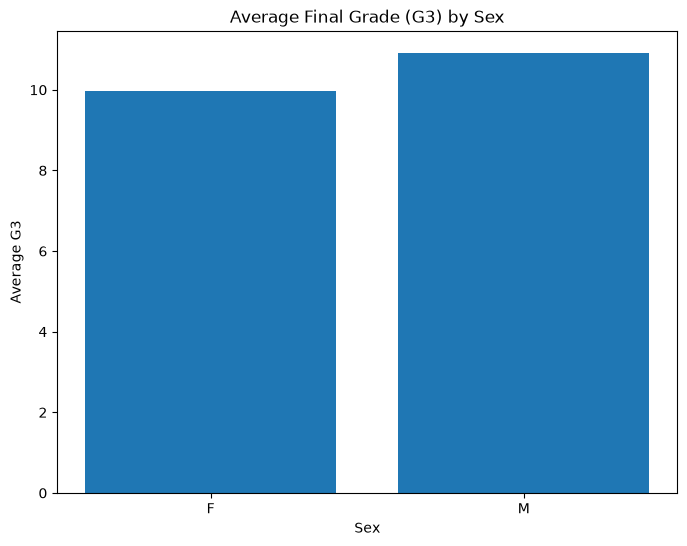

In [219]:
sex_g3 = sd.groupby("sex")["G3"].mean()

fig, ax = plt.subplots(figsize=(8,6))
ax.bar(sex_g3.index, sex_g3.values)
ax.set_title("Average Final Grade (G3) by Sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Average G3")
plt.show()